# Online Retail Sales Performance Analysis

## Project Overview

This project analyzes transactional sales data from an online retail store to identify
key revenue drivers, product performance, and sales trends over time.

The goal of the analysis is to understand which products generate the most revenue,
how sales evolve over time, and whether revenue is concentrated among a small number
of products or markets.

Dataset used in this project:
UCI Online Retail Dataset – a real-world transactional dataset containing
purchases made by an online retail company between 2010 and 2011.

The analysis is performed using Python, pandas, and matplotlib in Jupyter Notebook.

## Business Questions

The analysis aims to answer the following questions:

1. What is the overall sales performance of the company?
2. Which products generate the highest revenue?
3. Are sales concentrated in a small number of products (Pareto effect)?
4. How does revenue change over time?
5. Which countries generate the most revenue?

## Data Loading

The dataset used in this project is the Online Retail dataset from the UCI Machine Learning Repository.

It contains transactional data for purchases made by customers of an online retail store between 2010 and 2011.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_raw = pd.read_csv("Online_Retail.csv", encoding="ISO-8859-1", sep=";",decimal=",")

df = df_raw.copy()

## Initial Data Analysis (IDA)

Before performing data cleaning and analysis, we first explore the dataset
to understand its structure, variables, and potential data quality issues.

### Dataset Shape

Check the number of rows and columns in the dataset.

In [3]:
df.shape

(541909, 8)

The dataset contains transactional records with multiple variables describing
each purchase, including invoice number, product description, quantity, price,
and customer location.

### Data Preview

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01.12.2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01.12.2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01.12.2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01.12.2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01.12.2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
480252,577296,22144,CHRISTMAS CRAFT LITTLE FRIENDS,1,18.11.2011 12:47,2.10,17286.0,United Kingdom
258274,559603,79337,NaN,1,11.07.2011 11:27,0.00,NaN,United Kingdom
422117,573038,21908,CHOCOLATE THIS WAY METAL SIGN,1,27.10.2011 13:48,2.10,17545.0,United Kingdom
233641,557481,22697,GREEN REGENCY TEACUP AND SAUCER,1,20.06.2011 14:11,5.79,NaN,United Kingdom
151927,549572,21035,SET/2 RED RETROSPOT TEA TOWELS,3,10.04.2011 15:32,3.25,17757.0,United Kingdom


### Dataset Structure

Inspect column names and data types.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


The dataset contains both numerical and categorical variables.
The InvoiceDate column represents the timestamp of each transaction.
CustomerID contains missing values, which may affect customer-level analysis.

### Summary Statistics

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


The dataset shows variability in quantities and prices, indicating
transactions of different sizes and product values.

### Missing Values

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing values are present in the CustomerID column.
These rows may represent guest transactions or incomplete records.

### Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(5268)

## Data Cleaning

In [10]:
# Remove cancellations
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove negative or zero quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [11]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,530104.000000,530104.000000,397884.000000
mean,10.542037,3.907625,15294.423453
std,155.524124,35.915681,1713.141560
min,1.000000,0.001000,12346.000000
25%,1.000000,1.250000,13969.000000
50%,3.000000,2.080000,15159.000000
75%,10.000000,4.130000,16795.000000
max,80995.000000,13541.330000,18287.000000


In [12]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]
df["Sales"].describe()

count    530104.000000
mean         20.121871
std         270.356743
min           0.001000
25%           3.750000
50%           9.900000
75%          17.700000
max      168469.600000
Name: Sales, dtype: float64

In [13]:
total_revenue = df["Sales"].sum()
print("Total Revenue:", round(total_revenue, 2),)

Total Revenue: 10666684.54


Total revenue represents the overall sales performance during the analyzed period and serves as a baseline KPI for business evaluation.

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True,  errors="coerce")

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

In [15]:
monthly_revenue = df.groupby("YearMonth")["Sales"].sum()
monthly_revenue.head()

YearMonth
2010-12    823746.140
2011-01    691364.560
2011-02    523631.890
2011-03    717639.360
2011-04    537808.621
Freq: M, Name: Sales, dtype: float64

In [16]:
df["InvoiceDate"].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

In [17]:
top_products = (
    df.groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products


Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64

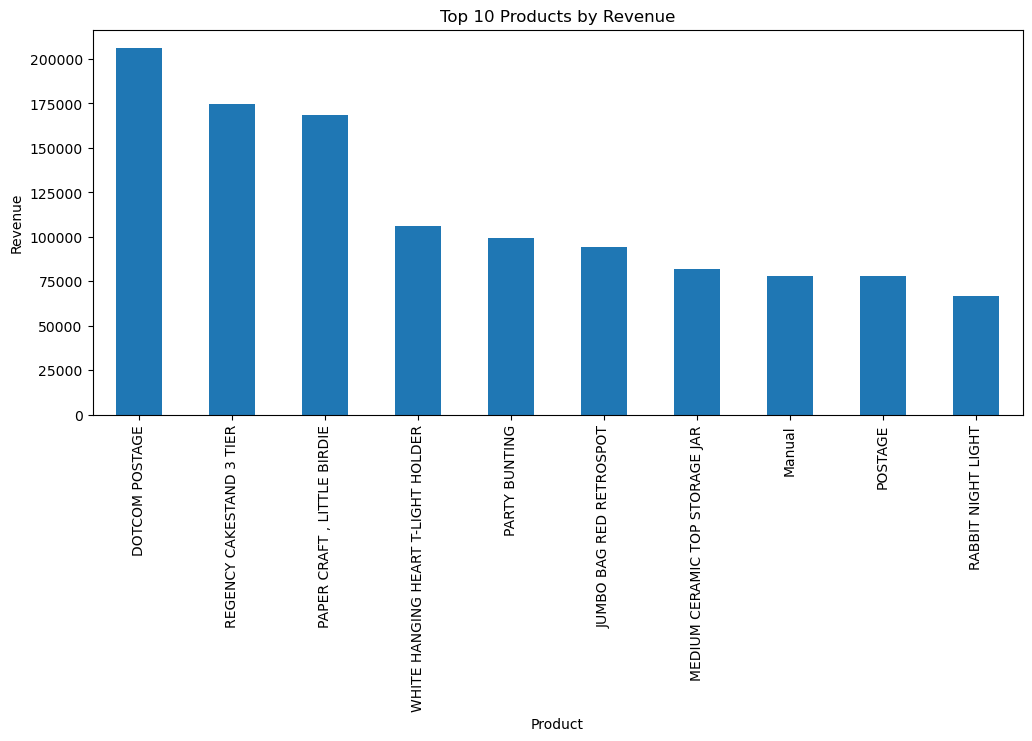

In [18]:
top_products.plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [19]:
top_quantity = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

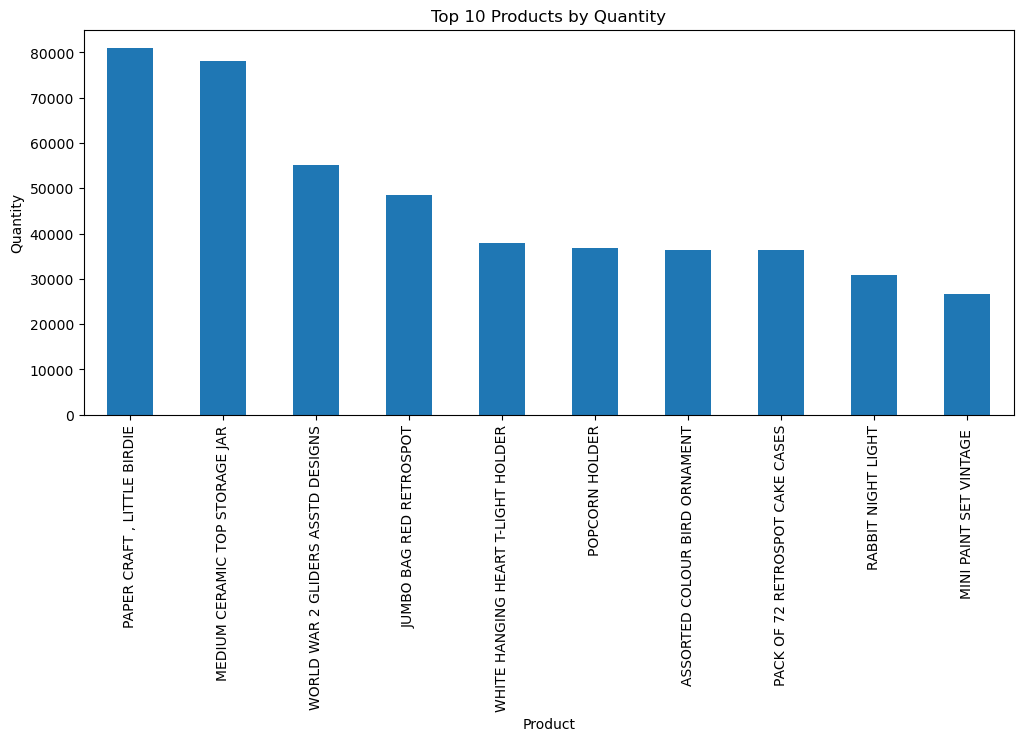

In [20]:
top_quantity.plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()

Revenue is influenced by both product price and sales volume.
Some products generate high revenue due to premium pricing,
while others rely on large quantities sold.

This highlights the importance of analyzing both revenue and quantity
when evaluating product performance.

In [21]:
df_products = df[~df["Description"].isin(["POSTAGE", "Manual"])]

In [22]:
top_products = (
    df_products.groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Non-product entries such as shipping charges (POSTAGE) and manual adjustments (Manual) were excluded from product-level analysis to focus on actual merchandise performance.

### Pareto Analysis (Product Revenue Distribution)

In many retail businesses, a small percentage of products generate a large share
of total revenue. This concept is known as the Pareto Principle or the 80/20 rule.

In this section, we analyze whether a small number of products account for the
majority of total sales revenue.

In [23]:
product_sales = (
    df.groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

In [24]:
pareto = product_sales.cumsum() / product_sales.sum()

In [25]:
pareto_df = pd.DataFrame({
    "Revenue": product_sales,
    "CumulativeRevenue": pareto
})

In [26]:
pareto_80 = pareto_df[pareto_df["CumulativeRevenue"] <= 0.8]

num_products_80 = pareto_80.shape[0]
total_products = pareto_df.shape[0]

print(f"{num_products_80} products generate 80% of revenue.")
print(f"Total number of products: {total_products}")

828 products generate 80% of revenue.
Total number of products: 4026


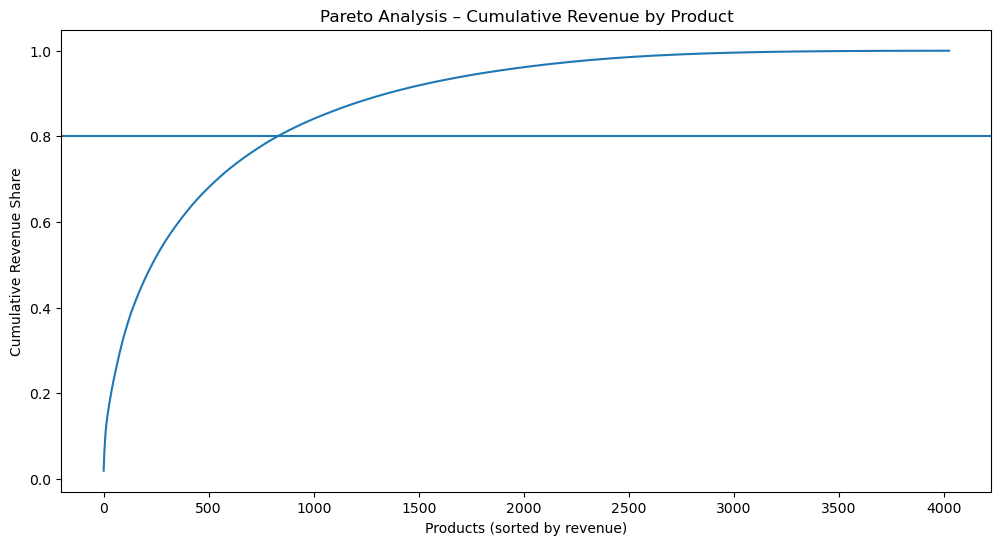

In [27]:
plt.figure(figsize=(12,6))

plt.plot(pareto_df["CumulativeRevenue"].values)

plt.axhline(0.8)

plt.title("Pareto Analysis – Cumulative Revenue by Product")
plt.xlabel("Products (sorted by revenue)")
plt.ylabel("Cumulative Revenue Share")

plt.show()

### Interpretation

The Pareto analysis shows that revenue is highly concentrated among a relatively
small number of products. A limited subset of products generates the majority
of total sales.

This pattern is common in retail businesses, where a small number of high-performing
items drive most of the revenue.

Understanding this distribution helps businesses prioritize inventory management,
marketing focus, and product strategy.

In [28]:
product_sales = (
    df_products.groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

### Geographic Revenue Distribution

In addition to product performance, it is important to understand
how revenue is distributed across different geographic markets.

Analyzing revenue by country helps identify the company's key markets
and highlights regions that contribute the most to overall sales.

This insight can support strategic decisions such as market expansion,
targeted marketing campaigns, and inventory planning.

In [29]:
country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

While the UK accounts for the majority of revenue, several international
markets also contribute to overall sales, indicating the presence of
cross-border e-commerce activity.

## Key Insights and Conclusions

This analysis explored transactional data from an online retail company
to understand revenue patterns, product performance, and geographic distribution
of sales.

Several key findings emerged from the analysis:

• Revenue is highly concentrated among a relatively small number of products,
  indicating a strong Pareto effect.

• Product performance is influenced by both sales volume and product pricing.
  Some items generate high revenue through large sales quantities, while others
  rely on higher unit prices.

• Sales revenue varies over time, suggesting potential seasonal patterns
  in customer demand.

• Revenue is strongly concentrated in a limited number of geographic markets,
  with the United Kingdom accounting for the majority of sales.

Overall, the results highlight the importance of focusing on top-performing
products and key markets when making business decisions related to inventory,
marketing, and sales strategy.

### Data export

In [30]:
#df.to_excel("online_retail_cleaned.xlsx", index=False)

In [31]:
#df.to_csv("online_retail_cleaned.csv", index=False)